## 1. What this notebook computes

Einstein's field equations equate the Einstein tensor $G$, built from the curvature
of space-time, to the energy and momentum of matter. In eight dimensions Lovelock's
theorem allows two more tensors of the same kind, built from products of two and of
three curvature tensors. Together with Einstein's they are the three **Lovelock
tensors** $P_{(1)}, P_{(2)}, P_{(3)}$ of Lovelock's equation (4.38), which the
author's notebook quotes. This notebook computes them for the author's metric, in
two independent ways, and checks them. It

- builds the Revision Rust program `lovelock_gkd` with cargo and runs it: from the
  metric alone it computes exactly the Christoffel symbols, the Riemann tensor and
  the three Lovelock tensors (with GKD, the generalized Kronecker delta), checks 19
  identities, and writes four files; the notebook checks that the four files are,
  byte for byte, the committed Revision records;
- draws how much work the sums are, and how the program reduces it;
- recomputes the Riemann tensor with sympy and compares all 156 nonzero components
  exactly with the record; draws the curvature of every coordinate plane and the
  whole Riemann tensor, and shows why the mixed $x_4$-$x_8$ terms cancel;
- recomputes the three Lovelock tensors and the three Lovelock scalars in Python
  with its own GKD sum and its own exact polynomial arithmetic, reproduces the
  counters of the Rust sums, and compares all $3 \times 64$ components exactly;
- checks three classical identities: $P_{(1)} = -4\,G$ (Einstein), $P_{(2)} = -8\,H$
  with the Gauss-Bonnet tensor $H$, and $L_{(3)} = 8 \times$ the cubic Lovelock
  density; the trace identities; and $P_{(4)} = 0$.

It draws four figures and takes about one minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 11b (The three Lovelock tensors of the author's metric, computed with GKD) is
the file `Revision/textbook/notebooks/11b_lovelock_tensors.ipynb` of the repository
Dirac_claude. It builds and runs the Revision Rust program lovelock_gkd, which computes
exactly the curvature of the author's metric and the three Lovelock tensors of Lovelock's
equation (4.38) in eight dimensions with GKD, and checks that its four output files are
byte for byte the committed Revision records; then it recomputes the Riemann tensor with
sympy and the three Lovelock tensors and scalars with its own Python GKD sum, compares
every component exactly with the records, reproduces the counters of the Rust sums, and
checks that the first Lovelock tensor is -4 times the Einstein tensor, the second -8
times the Gauss-Bonnet tensor, the third scalar 8 times the cubic Lovelock density, that
the traces obey the trace identity and that the fourth tensor vanishes; it draws four
teaching figures. The Rust program writes its four output files (curvature.json,
lovelock-tensors.json, lovelock-components.md and lovelock-report.json) into the folder
`Revision/gkd_lovelock/code/target/textbook_11b`, inside the Rust build folder, which git
ignores. It needs a computer with Windows 11, macOS or Linux, an internet connection for
the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It also needs Rust (the program cargo, version 1.91.1 or newer), because it
runs the Rust program lovelock_gkd, which is part of the repository and is built on your
computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/gkd_lovelock/code/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/gkd_lovelock/code/target/release/lovelock_gkd` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 11b_lovelock_tensors.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 1 minute on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 11b_lovelock_tensors.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
11b_lovelock_tensors.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/11b.captions.json`
- `Revision/textbook/figures/11b_1_work_of_the_sums.png`
- `Revision/textbook/figures/11b_2_curvature_of_planes.png`
- `Revision/textbook/figures/11b_3_riemann_matrix.png`
- `Revision/textbook/figures/11b_4_mixing_terms_cancel.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds; running it headless or saving it in JupyterLab also rewrites
the notebook file itself. It does not use the internet while it runs. The files it writes
are the same files that are stored in the repository (on another computer a figure may
differ in a few bytes, which is harmless). To get the stored versions back, run this
command in the repository folder (it also undoes every change you made yourself in the
folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all four figure files of the notebook exist
    ALL 29 CHECKS PASSED (notebook 11b)

and the notebook must show 4 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/11b_lovelock_tensors.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.
- AssertionError: check failed: the program wrote curvature.json equal to the Revision
  record byte for byte (or the same message for one of the other three files): The file
  that the program wrote differs from the committed record. Run git status in the
  repository folder to see whether the records or the Rust source were changed, and
  restore both with the command below.

      git checkout -- Revision/gkd_lovelock

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 11b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 11b (The three Lovelock tensors of the author's metric, computed with GKD) is
# the file Revision/textbook/notebooks/11b_lovelock_tensors.ipynb of the repository
# Dirac_claude. It builds and runs the Revision Rust program lovelock_gkd, which computes
# exactly the curvature of the author's metric and the three Lovelock tensors of
# Lovelock's equation (4.38) in eight dimensions with GKD, and checks that its four
# output files are byte for byte the committed Revision records; then it recomputes the
# Riemann tensor with sympy and the three Lovelock tensors and scalars with its own
# Python GKD sum, compares every component exactly with the records, reproduces the
# counters of the Rust sums, and checks that the first Lovelock tensor is -4 times the
# Einstein tensor, the second -8 times the Gauss-Bonnet tensor, the third scalar 8 times
# the cubic Lovelock density, that the traces obey the trace identity and that the fourth
# tensor vanishes; it draws four teaching figures. The Rust program writes its four
# output files (curvature.json, lovelock-tensors.json, lovelock-components.md and
# lovelock-report.json) into the folder Revision/gkd_lovelock/code/target/textbook_11b,
# inside the Rust build folder, which git ignores. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It also needs Rust (the program
# cargo, version 1.91.1 or newer), because it runs the Rust program lovelock_gkd, which
# is part of the repository and is built on your computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/gkd_lovelock/code/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/gkd_lovelock/code/target/release/lovelock_gkd (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 11b_lovelock_tensors.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 1 minute
# on a typical laptop. Scroll to the end and compare the last printed lines with the
# lines in the step "What the notebook writes and what you must see" below. To keep the
# results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose the
# menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 11b_lovelock_tensors.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 11b_lovelock_tensors.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/11b.captions.json
# - Revision/textbook/figures/11b_1_work_of_the_sums.png
# - Revision/textbook/figures/11b_2_curvature_of_planes.png
# - Revision/textbook/figures/11b_3_riemann_matrix.png
# - Revision/textbook/figures/11b_4_mixing_terms_cancel.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds; running it headless or saving it in JupyterLab also rewrites
# the notebook file itself. It does not use the internet while it runs. The files it
# writes are the same files that are stored in the repository (on another computer a
# figure may differ in a few bytes, which is harmless). To get the stored versions back,
# run this command in the repository folder (it also undoes every change you made
# yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all four figure files of the notebook exist
#     ALL 29 CHECKS PASSED (notebook 11b)
#
# and the notebook must show 4 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/11b_lovelock_tensors.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
# - AssertionError: check failed: the program wrote curvature.json equal to the Revision
#   record byte for byte (or the same message for one of the other three files): The file
#   that the program wrote differs from the committed record. Run git status in the
#   repository folder to see whether the records or the Rust source were changed, and
#   restore both with the command below.
#     git checkout -- Revision/gkd_lovelock
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "11b"  # this notebook: chapter 11, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 11b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$ of the author's metric: $x_1, x_2, x_3$ ordinary
  space, $x_4$ the time, $x_5, x_6, x_7$ the three extra times, $x_8$ the hidden
  direction. The programs number them $0, \dots, 7$.
- **Metric** $g_{ab}$: the table of numbers that gives lengths and times; here it is
  diagonal (only $g_{11}, \dots, g_{88}$ are not zero). **Inverse metric**
  $g^{aa} = 1/g_{aa}$ for a diagonal metric.
- **Index up, index down**: a tensor component carries upper and lower coordinate
  labels, such as $R^{ab}{}_{cd}$; a label is raised with the inverse metric.
- **Christoffel symbol** $\Gamma^a{}_{bc}$: the combination of first derivatives of
  the metric that says how the coordinate directions turn from point to point.
- **Riemann tensor** $R^a{}_{bcd}$: the combination of Christoffel symbols and their
  derivatives that measures curvature. We use mostly $R^{ab}{}_{cd} =
  g^{bb} R^a{}_{bcd}$, which changes sign when $a, b$ or $c, d$ are exchanged.
- **Curvature of a plane** $K(a, b) = R^{ab}{}_{ab}$ (no sum): the curvature of the
  surface spanned by the directions $x_a$ and $x_b$.
- **Ricci tensor** $R^h{}_j = \sum_a R^{ha}{}_{ja}$, **Ricci scalar**
  $R = \sum_h R^h{}_h$, **Einstein tensor** $G^h{}_j = R^h{}_j - \tfrac12
  \delta^h{}_j R$.
- **Generalized Kronecker delta, GKD**: the number $+1$, $-1$ or $0$ that weights
  every term of the Lovelock sums (built and tested in Notebook 11a).
- **Lovelock tensor** $P_{(k)}{}^h{}_j$ of order $k$, **Lovelock scalar**
  $L_{(k)}$: defined in section 4. **Gauss-Bonnet tensor**: the classical name of
  the order-2 Lovelock tensor.
- **Exact**: computed with whole numbers and fractions, without rounding.
  **Polynomial, monomial**: a polynomial is a sum of monomials, each a number times
  powers of symbols such as $H^2 a_4'^2$; a **Laurent polynomial** may also contain
  negative powers, such as $\cot^{-1}$.
- **Brute force**: a computation that tries every case without any shortcut.
- **Revision record**: a file committed under `Revision/` that holds a result.
  **Byte for byte**: two files equal in every byte.

## 4. The physical and mathematical situation

**The metric.** The author's primordial metric is diagonal,

$$g = \mathrm{diag}\big(e^{2a_4} s,\ e^{2a_4} s,\ e^{2a_4} s,\ -1,\
  -e^{-2a_4} s,\ -e^{-2a_4} s,\ -e^{-2a_4} s,\ \cot^2 z\big),\qquad
  s = \sin^{1/3} z,\quad z = 6 H x_8,$$

in the order $x_1, \dots, x_8$, with a constant $H > 0$ and a function $a_4(x_4)$ of
the time; $0 < z < \pi/2$. Lengths along ordinary space carry the scale factor
$e^{a_4} \sin^{1/6} z$ (it INFLATES as $a_4$ grows), lengths along the three extra
times the factor $e^{-a_4} \sin^{1/6} z$ (they DEFLATE exponentially), and
$\sqrt{|\det g|} = \cos z$. Primes are derivatives with respect to the time:
$a_4' = da_4/dx_4$, $a_4'' = d^2a_4/dx_4^2$. Below, $A_1$ stands for $a_4'$, $A_2$
for $a_4''$ and $C$ for $\cot z$.

**Curvature** (the convention of Misner, Thorne and Wheeler, used by the Revision):

$$\Gamma^a{}_{bc} = \tfrac12 g^{aa}\big(\partial_b g_{ac} + \partial_c g_{ab}
  - \partial_a g_{bc}\big),$$

$$R^a{}_{bcd} = \partial_c \Gamma^a{}_{db} - \partial_d \Gamma^a{}_{cb}
  + \sum_e \big(\Gamma^a{}_{ce} \Gamma^e{}_{db} - \Gamma^a{}_{de} \Gamma^e{}_{cb}\big),
  \qquad R^{ab}{}_{cd} = g^{bb} R^a{}_{bcd}.$$

(For a diagonal metric the sum $g^{ad}(\dots)$ of the general formula keeps only
$d = a$.)

**Lovelock's equation (4.38)** gives, for $n$ dimensions with $n = 2m$ even, the
tensors

$$P_{(k)}{}^h{}_j = \sum \delta^{h\, h_1 \dots h_{2k}}_{j\, j_1 \dots j_{2k}}\,
  R^{j_1 j_2}{}_{h_1 h_2} \cdots R^{j_{2k-1} j_{2k}}{}_{h_{2k-1} h_{2k}},$$

where the sum runs over all $4k$ labels $h_1, \dots, h_{2k}, j_1, \dots, j_{2k}$ and
$\delta$ is the generalized Kronecker delta with the upper list
$(h, h_1, \dots, h_{2k})$ and the lower list $(j, j_1, \dots, j_{2k})$. The orders
are $k = 1, \dots, m - 1$; for $n = 8$, $m = 4$ and $k = 1, 2, 3$. The **Lovelock
scalar** $L_{(k)}$ is the same sum without the free pair $h, j$. The equation itself
(with constants $\alpha_k$ and $\lambda$) is written with the densities
$A_{(k)}{}^{lh} = \sqrt{|\det g|}\, g^{ll} P_{(k)}{}^h{}_l$; the usual normalisation
is $E_{(k)} = -P_{(k)}/2^{k+1}$, so that $E_{(1)}$ is Einstein's tensor $G$. The
field equations of $a_4$ built from them are the subject of chapter 12.

**Why the sum must be organised.** Written literally, each component is a sum over
$8^{4k}$ lists of labels: $8^{12} \approx 6.9 \times 10^{10}$ terms per component for
$k = 3$. Two facts make it small. First, a term with a vanishing curvature factor
vanishes, so only the 156 nonzero $R^{ab}{}_{cd}$ need to be combined. Second, a
term in which a label repeats in the upper or in the lower list has GKD $= 0$
(Notebook 11a), so such combinations are skipped as soon as they appear. Every term
that remains is weighted by an explicit call of GKD. The Rust program and the Python
code of section 8 both follow this plan, written independently; the program also
checks it against the literal, unpruned sum for $k = 1$ and $k = 2$ at a numerical
point ("brute force").

**Status.** The tensors are exact polynomials, computed by two independent programs
and verified again by the Revision's sympy and Wolfram checks (records
`python-lovelock-report.json`, 49 checks, and `wolfram-gkd-report.json`, 29 checks):
PROVED by exact computation. No physical assumption enters this notebook: it is the
geometry of the given metric.

## 5. The Rust program `lovelock_gkd`

The next cell builds the program with cargo, through the helper `rust_program` of the
set-up cell (it runs `cargo build --release` for the crate
`Revision/gkd_lovelock/code`, a few seconds the first time and about a second when
the program is up to date) and returns the path of the program file.

In [2]:
program = rust_program("Revision/gkd_lovelock/code/Cargo.toml", "lovelock_gkd")

Rust program lovelock_gkd is built and ready.


The next cell runs `lovelock_gkd lovelock --output FOLDER --brute-force-k2`. FOLDER
is `Revision/gkd_lovelock/code/target/textbook_11b`, inside the crate's build folder
`target`, which git ignores; so the run adds no file to the repository. The program
computes everything exactly from the metric, runs its 19 checks (the option
`--brute-force-k2` adds the literal unpruned sum of order 2 over 1,073,741,824 index
lists at one numerical point) and writes four files: `curvature.json`,
`lovelock-tensors.json`, `lovelock-components.md` and `lovelock-report.json`. It
takes about 15 seconds.

The program prints one line per check (`PASS - name: detail` or `FAIL - ...`), one
line per order $k$ with its counters and run time, and an information line with the
eighth-order scalar $L_{(4)}$. The cell prints the names of the checks with their
verdicts, and $L_{(4)}$ in a readable form (the program writes $a_4'$ as
`Derivative[1][a4][x4]`, Mathematica's notation); it leaves out the run times, which
differ from run to run. `re.match` and `re.search` read parts of a line with a
pattern (a regular expression).

In [3]:
import re  # regular expressions: patterns that read parts of a line of text

RESULTS = "Revision/gkd_lovelock/results"  # the folder of the Revision records
OUT_FOLDER = REPO / "Revision" / "gkd_lovelock" / "code" / "target" / "textbook_11b"
completed = subprocess.run(
    [str(program), "lovelock", "--output", str(OUT_FOLDER), "--brute-force-k2"],
    capture_output=True, text=True, encoding="utf-8", errors="replace")
rust_checks = []  # (name, verdict) of every check the program printed
for line in completed.stdout.splitlines():
    found = re.match(r"(PASS|FAIL) - (\w+): ", line)
    if found:
        rust_checks.append((found.group(2), found.group(1)))
    if line.startswith("info - L_(4)"):
        l4_text = line.split("): ", 1)[1]  # the formula after the explanation
say("The checks of the Rust program (name, verdict):")
for number, (name, verdict) in enumerate(rust_checks, 1):
    say(f"  {number:2d} {name:34s} {verdict}")
readable = (l4_text.replace("Derivative[1][a4][x4]", "a4'").replace("*", " ")
            .replace("(", "").replace(")", ""))
report("eighth-order scalar printed by the program, L(4)", readable)
check(completed.returncode == 0 and "lovelock: SUCCESS" in completed.stdout,
      "the Rust program lovelock_gkd lovelock ended with SUCCESS")
check(len(rust_checks) == 19 and all(v == "PASS" for _, v in rust_checks),
      "all 19 checks of the Rust program passed",
      record=f"{RESULTS}/lovelock-report.json, checkCount 19, failedCheckCount 0")

The checks of the Rust program (name, verdict):
   1 riemann_antisymmetry               PASS
   2 riemann_first_bianchi              PASS
   3 mixed_riemann_free_of_sin_third    PASS
   4 k1_equals_minus_4_einstein         PASS
   5 k1_trace_identity                  PASS
   6 k1_divergence_free                 PASS
   7 k1_symmetric                       PASS
   8 k1_free_of_sin_third               PASS
   9 k2_trace_identity                  PASS
  10 k2_divergence_free                 PASS
  11 k2_symmetric                       PASS
  12 k2_free_of_sin_third               PASS
  13 k3_trace_identity                  PASS
  14 k3_divergence_free                 PASS
  15 k3_symmetric                       PASS
  16 k3_free_of_sin_third               PASS
  17 k4_tensor_vanishes                 PASS
  18 k1_brute_force_numeric             PASS
  19 k2_brute_force_numeric             PASS
RESULT eighth-order scalar printed by the program, L(4) = -663552 H^2 a4'^6 - 442368 H^4
    a4'^

The next cell compares the four files that the program has just written with the
committed Revision records in `Revision/gkd_lovelock/results`, byte for byte
(`read_bytes()` reads a file as a sequence of bytes). Equal bytes mean that the
program, built on this computer, has reproduced every symbol of the Revision's
results.

In [4]:
for file_name in ("curvature.json", "lovelock-tensors.json",
                  "lovelock-components.md", "lovelock-report.json"):
    written = (OUT_FOLDER / file_name).read_bytes()
    stored = repository_file(f"{RESULTS}/{file_name}").read_bytes()
    report(f"size of {file_name}", len(written), "bytes")
    check(written == stored,
          f"the program wrote {file_name} equal to the Revision record byte for byte",
          record=f"{RESULTS}/{file_name} (the whole file)")

RESULT size of curvature.json = 28162 bytes
PASS the program wrote curvature.json equal to the Revision record byte for byte
     reproduces Revision/gkd_lovelock/results/curvature.json (the whole file)
RESULT size of lovelock-tensors.json = 55056 bytes
PASS the program wrote lovelock-tensors.json equal to the Revision record byte for byte
     reproduces Revision/gkd_lovelock/results/lovelock-tensors.json (the whole file)
RESULT size of lovelock-components.md = 19604 bytes
PASS the program wrote lovelock-components.md equal to the Revision record byte for byte
     reproduces Revision/gkd_lovelock/results/lovelock-components.md (the whole file)
RESULT size of lovelock-report.json = 3154 bytes
PASS the program wrote lovelock-report.json equal to the Revision record byte for byte
     reproduces Revision/gkd_lovelock/results/lovelock-report.json (the whole file)


## 6. How much work the sums are

The report `lovelock-report.json` (just reproduced) lists, for each order $k$, the
**leaves** (the combinations of $k$ nonzero curvature entries that survive the
skipping of repeated labels, for all 64 pairs $(h, j)$), the **GKD calls** (the
leaves whose upper and lower label sets are equal, so that GKD may be nonzero; GKD
is then called) and the number of nonzero GKD values. The next cell reads them and
compares them with two counts without any shortcut: the number of ordered
combinations of $k$ of the 156 nonzero entries for the 64 pairs, $64 \cdot 156^k$,
and the literal number of index lists, $64 \cdot 8^{4k}$. For $k = 4$ nothing
survives: a combination of four entries needs nine different labels in each list,
and there are only eight.

order k   literal lists   ordered products    leaves   GKD calls   nonzero GKD
      1        2.62e+05           9.98e+03      5616         696           696
      2        1.07e+09           1.56e+06    176640       32640         32640
      3        4.40e+12           2.43e+08   1128960      495360        495360
      4        1.80e+16           3.79e+10         0           0             0


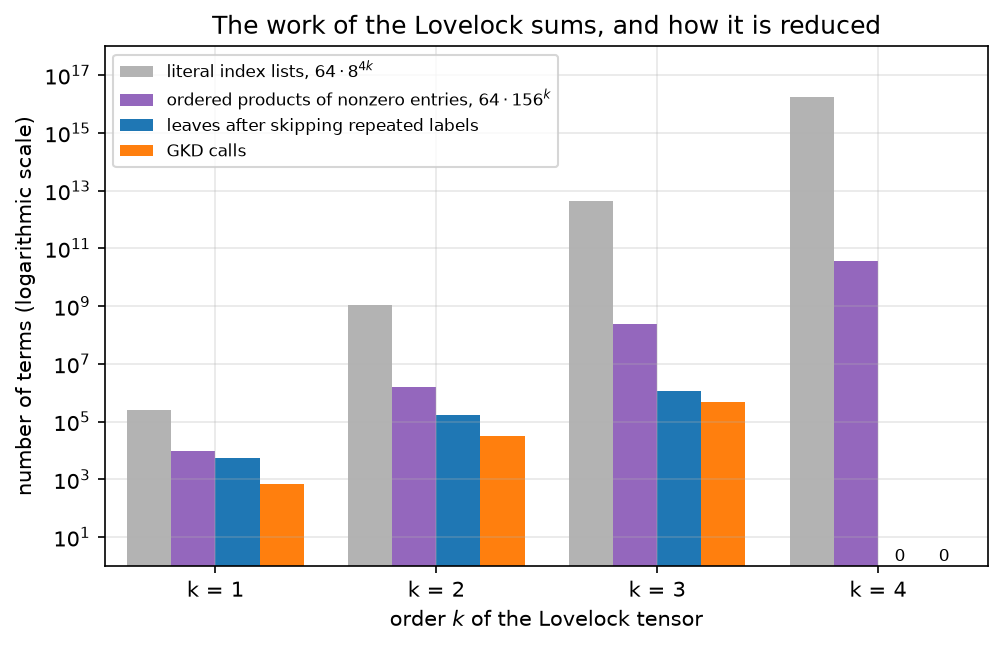

Figure 11b.1 saved as Revision/textbook/figures/11b_1_work_of_the_sums.png
PASS the counters of the Rust sums are 5616, 176640, 1128960, 0 leaves and 696, 32640,
    495360, 0 GKD calls


In [5]:
import numpy as np  # arrays of numbers

lovelock_report = json.loads((OUT_FOLDER / "lovelock-report.json").read_text(
    encoding="utf-8"))
COUNTERS = {row["k"]: row for row in lovelock_report["counters"]}
say("order k   literal lists   ordered products    leaves   GKD calls   nonzero GKD")
for k in (1, 2, 3, 4):
    leaves, calls = COUNTERS[k]["leaves"], COUNTERS[k]["gkdCalls"]
    nonzero = COUNTERS[k]["gkdNonzero"]
    say(f"      {k}   {64 * 8 ** (4 * k):13.2e}   {64 * 156 ** k:16.2e}   "
        f"{leaves:7d}   {calls:9d}   {nonzero:11d}")

fig, ax = plt.subplots(figsize=(7.6, 4.5))
orders = np.array([1, 2, 3, 4])
series = [("literal index lists, $64 \\cdot 8^{4k}$", [64 * 8 ** (4 * k)
                                                      for k in orders], "0.7"),
          ("ordered products of nonzero entries, $64 \\cdot 156^k$",
           [64 * 156 ** k for k in orders], "tab:purple"),
          ("leaves after skipping repeated labels",
           [COUNTERS[k]["leaves"] for k in orders], "tab:blue"),
          ("GKD calls", [COUNTERS[k]["gkdCalls"] for k in orders], "tab:orange")]
width = 0.2
for number, (name, heights, colour) in enumerate(series):
    place = orders + (number - 1.5) * width
    ax.bar(place, [h if h > 0 else np.nan for h in heights], width, color=colour,
           label=name)
    for x, h in zip(place, heights):
        if h == 0:
            ax.text(x, 1.5, "0", ha="center", fontsize=8)
ax.set_yscale("log")
ax.set_ylim(1.0, 1e18)
ax.set_xlim(0.5, 4.5)
ax.set_xticks(orders, [f"k = {k}" for k in orders])
ax.set_xlabel("order $k$ of the Lovelock tensor")
ax.set_ylabel("number of terms (logarithmic scale)")
ax.set_title("The work of the Lovelock sums, and how it is reduced")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "work_of_the_sums",
            "The number of terms of the Lovelock sums for the 64 components of "
            "$P_{(k)}$, order $k = 1$ to $4$, on a logarithmic vertical axis: all "
            "index lists of the literal formula (grey), the ordered products of $k$ "
            "of the 156 nonzero curvature entries (purple), the combinations left "
            "after skipping those with a repeated label (blue), and the ones for "
            "which GKD is called (orange). For $k = 3$ the literal sum has about "
            "$4.4 \\times 10^{12}$ terms, of which only 495,360 are evaluated; for "
            "$k = 4$ nothing is left, because nine labels out of eight must repeat.")
check([COUNTERS[k]["leaves"] for k in (1, 2, 3, 4)] == [5616, 176640, 1128960, 0]
      and [COUNTERS[k]["gkdCalls"] for k in (1, 2, 3, 4)] == [696, 32640, 495360, 0],
      "the counters of the Rust sums are 5616, 176640, 1128960, 0 leaves and 696, "
      "32640, 495360, 0 GKD calls")

## 7. The Riemann tensor, recomputed with sympy

The next two cells compute the curvature of the metric of section 4 with sympy, from
the formulas of section 4, without using anything of the Rust program. The first one
defines the metric and its Christoffel symbols. `sp.Function("a4")(x4)` is an
unknown function of the time; `sp.diff` differentiates exactly. Because the metric is
diagonal, the formula $\Gamma^a{}_{bc} = \tfrac12 g^{aa}(\partial_b g_{ac} +
\partial_c g_{ab} - \partial_a g_{bc})$ has at most three terms, each present only
when two of the labels $a, b, c$ are equal; the cell adds exactly those and keeps the
symbols that are not zero in the dictionary `christoffel`.

In [6]:
import sympy as sp  # exact algebra and calculus

H = sp.Symbol("H", positive=True)  # the author's constant H > 0
X = sp.symbols("x1:9", real=True)  # the coordinates x1, ..., x8
a4 = sp.Function("a4")(X[3])  # the unknown function a4(x4)
z = 6 * H * X[7]  # z = 6 H x8
warp = sp.sin(z) ** sp.Rational(1, 3)  # sin(z)^(1/3)
METRIC = ([sp.exp(2 * a4) * warp] * 3 + [sp.Integer(-1)]
          + [-sp.exp(-2 * a4) * warp] * 3 + [sp.cot(z) ** 2])  # g_11 ... g_88

christoffel = {}  # (a, b, c) -> Gamma^a_bc, only the nonzero ones
for a in range(8):
    for b in range(8):
        for c in range(8):
            value = 0
            if a == c:
                value += sp.diff(METRIC[a], X[b])  # d_b g_ac
            if a == b:
                value += sp.diff(METRIC[a], X[c])  # d_c g_ab
            if b == c:
                value -= sp.diff(METRIC[b], X[a])  # - d_a g_bc
            if value != 0:
                christoffel[a, b, c] = value / (2 * METRIC[a])  # times g^aa / 2


def gamma(a, b, c):
    """Gamma^a_bc (0 when it is not in the dictionary)."""
    return christoffel.get((a, b, c), 0)


christoffel_b_le_c = [key for key in christoffel if key[1] <= key[2]]
report("nonzero Christoffel symbols Gamma^a_bc with b <= c", len(christoffel_b_le_c))
check(all(christoffel.get((a, c, b)) == value
          for (a, b, c), value in christoffel.items()),
      "Gamma^a_bc = Gamma^a_cb (symmetric in the lower labels)")

RESULT nonzero Christoffel symbols Gamma^a_bc with b <= c = 25
PASS Gamma^a_bc = Gamma^a_cb (symmetric in the lower labels)


The next cell computes the Riemann tensor from the formula of section 4 and raises
its second label, $R^{ab}{}_{cd} = R^a{}_{bcd}/g_{bb}$. For every component it
replaces $a_4'$ and $a_4''$ by the symbols `A1` and `A2`, simplifies
(`sp.simplify`), and writes $\cot z$ as the symbol `C` (with $\tan z = 1/C$ and
$\cos z = C \sin z$). If a component still contained $x_8$, $\sin z$ or $e^{a_4}$,
the check at the end would fail: the warp factor $\sin^{1/3} z$ and the exponentials
cancel in every $R^{ab}{}_{cd}$. The cell takes about 10 seconds, almost all of it
in `sp.simplify`.

In [7]:
A1, A2, C = sp.symbols("A1 A2 C")  # a4', a4'' and cot(z)
SYMBOLS = {sp.Derivative(a4, (X[3], 2)): A2, sp.Derivative(a4, X[3]): A1}
RIEMANN = {}  # (a, b, c, d) -> R^ab_cd in the symbols H, A1, A2, C
for a in range(8):
    for b in range(8):
        for c in range(8):
            for d in range(8):
                value = sp.diff(gamma(a, d, b), X[c]) - sp.diff(gamma(a, c, b), X[d])
                for e in range(8):
                    value += (gamma(a, c, e) * gamma(e, d, b)
                              - gamma(a, d, e) * gamma(e, c, b))
                if value == 0:
                    continue
                value = sp.simplify((value / METRIC[b]).subs(SYMBOLS))  # R^ab_cd
                value = sp.expand(value.subs({sp.tan(z): 1 / C, sp.cot(z): C,
                                              sp.cos(z): C * sp.sin(z)}))
                if value != 0:
                    RIEMANN[a, b, c, d] = value
report("nonzero components R^ab_cd", len(RIEMANN))
check(all(v.free_symbols <= {H, A1, A2, C} for v in RIEMANN.values()),
      "every R^ab_cd is a polynomial in H, a4', a4'' and cot z and its inverse, free "
      "of sin(z)^(1/3) and e^a4",
      record=f"{RESULTS}/lovelock-report.json, check mixed_riemann_free_of_sin_third")

RESULT nonzero components R^ab_cd = 156
PASS every R^ab_cd is a polynomial in H, a4', a4'' and cot z and its inverse, free of
    sin(z)^(1/3) and e^a4
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    mixed_riemann_free_of_sin_third


The next cell reads the 156 components that the Rust program wrote into
`curvature.json` (as Mathematica text such as
`H*Derivative[1][a4][x4]*Cot[6*H*x8]^(-1)`), turns each into a sympy expression by
replacing the Mathematica names with `A1`, `A2`, `C` and `^` with `**`, and checks
that the two computations give the same nonzero components with EXACTLY the same
values (`sp.expand(mine - theirs) == 0`). It also checks the antisymmetry
$R^{ab}{}_{cd} = -R^{ba}{}_{cd} = -R^{ab}{}_{dc}$, the number of Christoffel symbols
and the Ricci scalar $R = \sum_{a,b} R^{ab}{}_{ab}$.

In [8]:
curvature = json.loads((OUT_FOLDER / "curvature.json").read_text(encoding="utf-8"))
NAMES = curvature["coordinates"]  # ["x1", ..., "x8"]


def from_mathematica(text):
    """A component written by the Rust program, as a sympy expression."""
    text = re.sub(r"Derivative\[(\d)\]\[a4\]\[x4\]", r"A\1", text)  # a4' -> A1
    text = text.replace("Cot[6*H*x8]", "C").replace("^", "**")
    return sp.sympify(text, locals={"H": H, "A1": A1, "A2": A2, "C": C})


rust_riemann = {}
for item in curvature["riemannMixedNonzero"]:
    a, b = (NAMES.index(name) for name in item["up"])
    c, d = (NAMES.index(name) for name in item["down"])
    rust_riemann[a, b, c, d] = from_mathematica(item["value"])
same_values = set(rust_riemann) == set(RIEMANN) and all(
    sp.expand(RIEMANN[key] - rust_riemann[key]) == 0 for key in RIEMANN)
check(same_values, "sympy and Rust give the same 156 nonzero R^ab_cd exactly",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, "
             "check rust_riemann_agrees")
antisymmetric = all(sp.expand(v + RIEMANN.get((b, a, c, d), 0)) == 0 and
                    sp.expand(v + RIEMANN.get((a, b, d, c), 0)) == 0
                    for (a, b, c, d), v in RIEMANN.items())
check(antisymmetric, "R^ab_cd = -R^ba_cd = -R^ab_dc for all components",
      record=f"{RESULTS}/lovelock-report.json, check riemann_antisymmetry")
check(len(christoffel_b_le_c) == len(curvature["christoffelNonzero_b_le_c"]) == 25,
      "25 nonzero Christoffel symbols with b <= c, as in the record")
ricci_scalar = sp.expand(sum(RIEMANN.get((a, b, a, b), 0) for a in range(8)
                             for b in range(8)))
report("Ricci scalar R", ricci_scalar)
check(sp.expand(ricci_scalar - from_mathematica(curvature["ricciScalar"])) == 0,
      "the Ricci scalar is R = 6 a4'^2 - 42 H^2, as in the record",
      record=f"{RESULTS}/curvature.json, ricciScalar")

PASS sympy and Rust give the same 156 nonzero R^ab_cd exactly
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    rust_riemann_agrees
PASS R^ab_cd = -R^ba_cd = -R^ab_dc for all components
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    riemann_antisymmetry
PASS 25 nonzero Christoffel symbols with b <= c, as in the record
RESULT Ricci scalar R = 6*A1**2 - 42*H**2
PASS the Ricci scalar is R = 6 a4'^2 - 42 H^2, as in the record
     reproduces Revision/gkd_lovelock/results/curvature.json, ricciScalar


The next cell draws the curvature of every coordinate plane, $K(a, b) =
R^{ab}{}_{ab}$, as two $8 \times 8$ tables of coloured squares, in units of $H^2$
(that is, with $H = 1$). The left table is a moment of the exponentially deflating
history $a_4 = A H x_4$ with $A = 2$, so $a_4' = 2H$ and $a_4'' = 0$; the right
table has the same $a_4'$ and $a_4'' = H^2$. The function `value_at` puts numbers in
place of the symbols (`expr.subs(...)`), and `float` turns the exact result into a
decimal number. The table is symmetric, $K(a, b) = K(b, a)$. Reading it: inside
ordinary space and inside the extra times $K = a_4'^2 - H^2$; between them
$K = -(a_4'^2 + H^2)$; with the time $x_4$, $K = a_4'^2 + a_4''$ for ordinary space
and $a_4'^2 - a_4''$ for the extra times; with the hidden direction $x_8$,
$K = -H^2$; the time and the hidden direction together are flat.

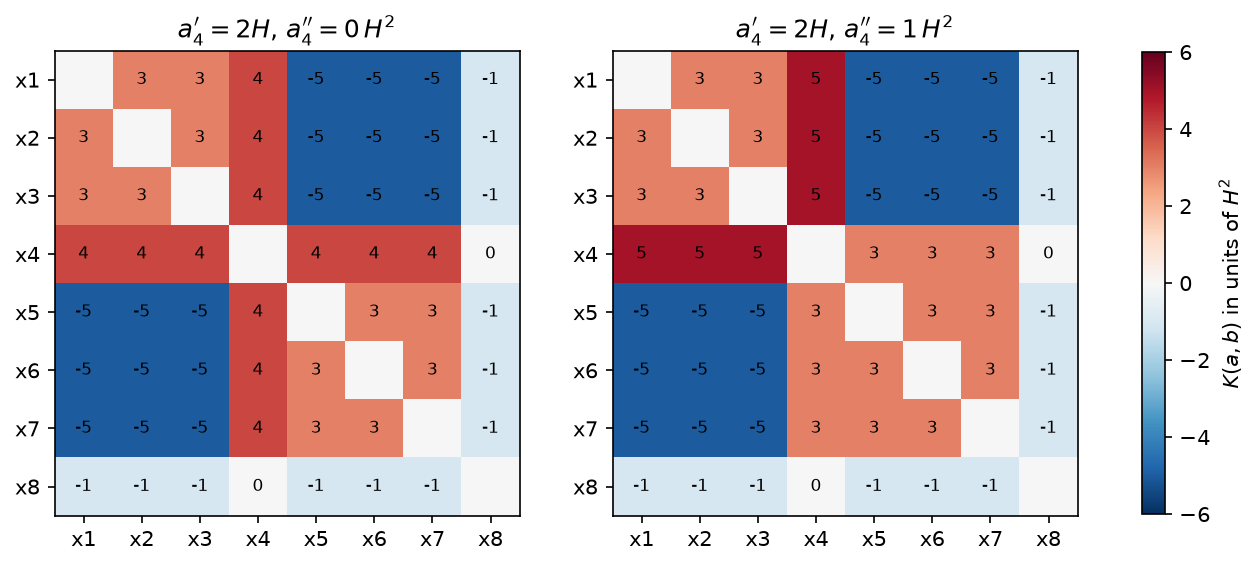

Figure 11b.2 saved as Revision/textbook/figures/11b_2_curvature_of_planes.png
PASS plane curvatures at a4' = 2H: 3, -5, -1; with x4: 4 + a4'' and 4 - a4''; x4 with x8:
    0


In [9]:
def value_at(expr, h=1.0, a1=2.0, a2=0.0, cot=1.0):
    """The number expr takes at H = h, a4' = a1, a4'' = a2, cot z = cot."""
    return float(sp.sympify(expr).subs({H: h, A1: a1, A2: a2, C: cot}))


fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))
planes = {}
for ax, a2 in zip(axes, (0.0, 1.0)):
    table = np.array([[value_at(RIEMANN.get((a, b, a, b), 0), a2=a2)
                       for b in range(8)] for a in range(8)])
    planes[a2] = table
    picture = ax.imshow(table, cmap="RdBu_r", vmin=-6, vmax=6)
    for a in range(8):
        for b in range(8):
            if a != b:
                ax.text(b, a, f"{table[a, b]:g}", ha="center", va="center",
                        fontsize=8)
    ax.set_xticks(range(8), NAMES)
    ax.set_yticks(range(8), NAMES)
    ax.set_title(f"$a_4' = 2H$, $a_4'' = {a2:g}\\,H^2$")
    ax.grid(False)
fig.colorbar(picture, ax=list(axes), shrink=0.8, label="$K(a, b)$ in units of $H^2$")
save_figure(fig, "curvature_of_planes",
            "The curvature $K(a, b) = R^{ab}_{\\ ab}$ of the plane of the coordinate "
            "directions $x_a$ and $x_b$, in units of $H^2$, for $a_4^{\\prime} = 2H$ "
            "and $a_4^{\\prime\\prime} = 0$ (left, a moment of the exponentially "
            "deflating history $a_4 = 2 H x_4$) and $a_4^{\\prime\\prime} = H^2$ "
            "(right); red is positive, blue negative, the diagonal is left empty. "
            "Planes inside ordinary space or inside the extra times have "
            "$K = a_4^{\\prime 2} - H^2 = 3$, planes between them "
            "$K = -(a_4^{\\prime 2} + H^2) = -5$, planes with $x_8$ have $K = -1$, "
            "and the time $x_4$ couples to space with $a_4^{\\prime 2} + "
            "a_4^{\\prime\\prime}$ and to the extra times with $a_4^{\\prime 2} - "
            "a_4^{\\prime\\prime}$: only these entries change on the right.")
check(planes[0.0][0, 1] == 3.0 and planes[0.0][0, 4] == -5.0
      and planes[0.0][0, 7] == -1.0 and planes[1.0][0, 3] == 5.0
      and planes[1.0][4, 3] == 3.0 and planes[0.0][3, 7] == 0.0,
      "plane curvatures at a4' = 2H: 3, -5, -1; with x4: 4 + a4'' and 4 - a4''; "
      "x4 with x8: 0")

The next cell draws the WHOLE tensor $R^{ab}{}_{cd}$ at one point as a
$64 \times 64$ table: row number $8a + b$ belongs to the upper pair $(x_a, x_b)$ and
column number $8c + d$ to the lower pair $(x_c, x_d)$. The point is $H = 1$,
$a_4' = 2$, $a_4'' = 1$ and $z = \pi/3$, where $\cot z = 1/\sqrt{3}$. Thin lines
separate the blocks of the first labels $a$ and $c$. Most squares are white: only 156
of the 4096 components are not zero. The squares far from the two diagonals are the
terms that MIX the time $x_4$ and the hidden direction $x_8$, such as
$R^{x_1 x_4}{}_{x_1 x_8} = H a_4' \cot z$.

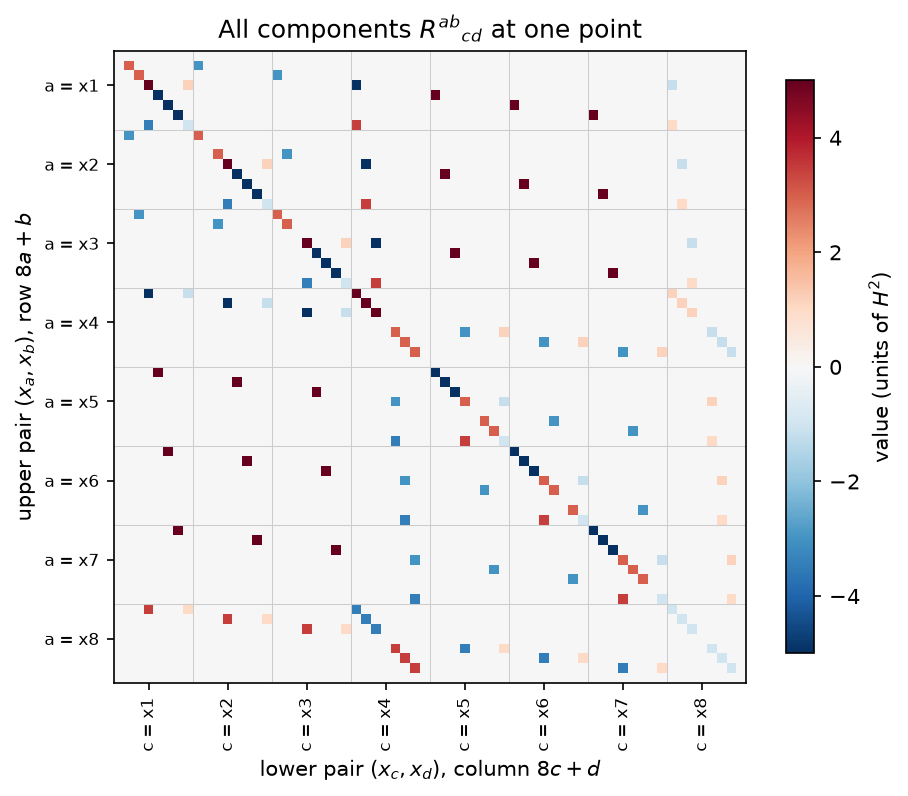

Figure 11b.3 saved as Revision/textbook/figures/11b_3_riemann_matrix.png
PASS 156 of the 4096 components are not zero at this point


In [10]:
point = {"h": 1.0, "a1": 2.0, "a2": 1.0, "cot": 1.0 / np.sqrt(3.0)}
whole = np.zeros((64, 64))
for (a, b, c, d), value in RIEMANN.items():
    whole[8 * a + b, 8 * c + d] = value_at(value, **point)
fig, ax = plt.subplots(figsize=(6.8, 6.2))
largest = np.abs(whole).max()
picture = ax.imshow(whole, cmap="RdBu_r", vmin=-largest, vmax=largest)
for edge in range(8, 64, 8):  # lines between the blocks
    ax.axhline(edge - 0.5, color="0.8", lw=0.5)
    ax.axvline(edge - 0.5, color="0.8", lw=0.5)
ticks = list(range(3, 64, 8))  # the middle of each block
ax.set_xticks(ticks, [f"c = {name}" for name in NAMES], rotation=90, fontsize=8)
ax.set_yticks(ticks, [f"a = {name}" for name in NAMES], fontsize=8)
ax.set_xlabel("lower pair $(x_c, x_d)$, column $8c + d$")
ax.set_ylabel("upper pair $(x_a, x_b)$, row $8a + b$")
ax.set_title("All components $R^{ab}{}_{cd}$ at one point")
ax.grid(False)
fig.colorbar(picture, ax=ax, shrink=0.8, label="value (units of $H^2$)")
save_figure(fig, "riemann_matrix",
            "All 4096 components of the Riemann tensor $R^{ab}_{\\ \\ cd}$ of the "
            "author's metric at the point $H = 1$, $a_4^{\\prime} = 2$, "
            "$a_4^{\\prime\\prime} = 1$, $z = \\pi/3$, arranged as a 64 by 64 table: "
            "row $8a + b$ is the upper pair of labels, column $8c + d$ the lower "
            "pair, counted from 0; red is positive, blue negative, white zero. Only "
            "156 components are not zero. The two diagonals hold the curvatures of "
            "the coordinate planes and their sign-reversed copies; the scattered "
            "squares between them mix the time $x_4$ with the hidden direction "
            "$x_8$.")
check(int(np.count_nonzero(whole)) == 156,
      "156 of the 4096 components are not zero at this point")

Why do the mixed $x_4$-$x_8$ terms not enter Einstein's tensor? The Ricci component
$R^{x_4}{}_{x_8} = \sum_c R^{x_4 c}{}_{x_8 c}$ adds one term for each direction $c$.
The next cell lists these seven terms: each of the three space directions gives
$+H a_4' \cot z$, each of the three extra times $-H a_4' \cot z$, and the hidden
direction itself gives 0. The sum vanishes EXACTLY, for every $a_4$, because there
are as many inflating as deflating directions. The cell draws the seven terms at the
point $H = 1$, $a_4' = 1$, $z = \pi/4$ ($\cot z = 1$).

R^(x4 x1)_(x8 x1) = A1*C*H
R^(x4 x2)_(x8 x2) = A1*C*H
R^(x4 x3)_(x8 x3) = A1*C*H
R^(x4 x4)_(x8 x4) = 0
R^(x4 x5)_(x8 x5) = -A1*C*H
R^(x4 x6)_(x8 x6) = -A1*C*H
R^(x4 x7)_(x8 x7) = -A1*C*H
sum over c = 0


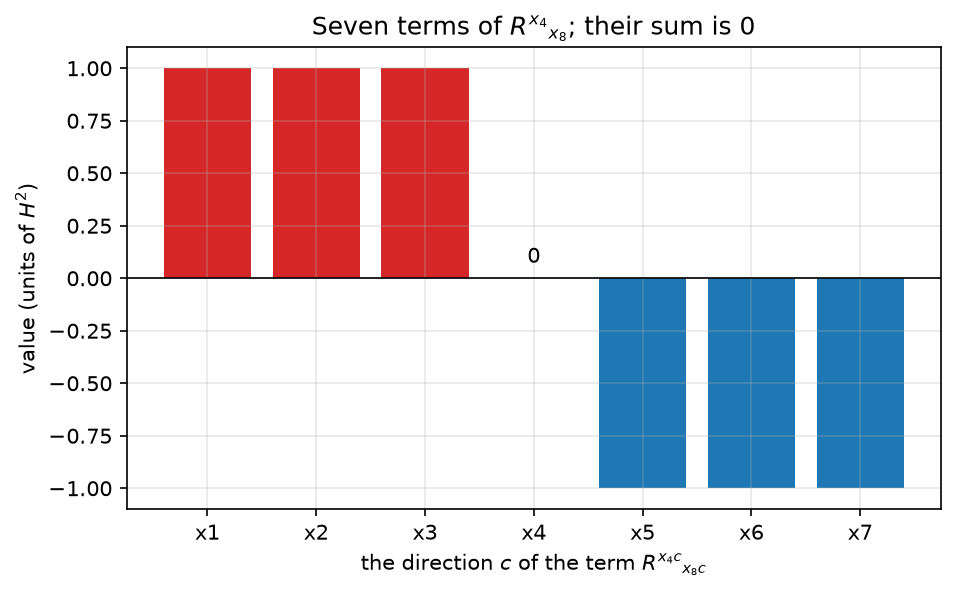

Figure 11b.4 saved as Revision/textbook/figures/11b_4_mixing_terms_cancel.png
PASS the seven terms of R^x4_x8 are +H a4' cot z (three times), -H a4' cot z (three
    times) and 0, and cancel exactly


In [11]:
mixing = [sp.expand(RIEMANN.get((3, c, 7, c), 0)) for c in range(7)]  # c = x1..x7
for c, term in enumerate(mixing):
    say(f"R^(x4 {NAMES[c]})_(x8 {NAMES[c]}) = {term}")
total = sp.expand(sum(mixing))
say(f"sum over c = {total}")
fig, ax = plt.subplots(figsize=(7.0, 4.0))
heights = [value_at(term, h=1.0, a1=1.0, cot=1.0) for term in mixing]
colours = ["tab:red"] * 3 + ["0.6"] + ["tab:blue"] * 3
ax.bar(NAMES[:7], heights, color=colours)
ax.text(3, 0.05, "0", ha="center", va="bottom")  # the term of c = x4 is zero
ax.axhline(0.0, color="black", lw=0.8)
ax.set_xlabel("the direction $c$ of the term $R^{x_4 c}{}_{x_8 c}$")
ax.set_ylabel("value (units of $H^2$)")
ax.set_title(f"Seven terms of $R^{{x_4}}{{}}_{{x_8}}$; their sum is {total}")
save_figure(fig, "mixing_terms_cancel",
            "The seven terms $R^{x_4 c}_{\\ \\ x_8 c}$, $c = x_1$ to $x_7$, whose sum "
            "is the Ricci component $R^{x_4}_{\\ x_8}$, at $H = 1$, "
            "$a_4^{\\prime} = 1$, $\\cot z = 1$, in units of $H^2$: the three space "
            "directions (red) give $+H a_4^{\\prime} \\cot z$ each, the three extra "
            "times (blue) $-H a_4^{\\prime} \\cot z$ each, and the time direction "
            "itself (grey) gives 0. Three inflating and three deflating directions "
            "cancel exactly, so Einstein's tensor and, as section 8 shows, all three "
            "Lovelock tensors have no $x_4$-$x_8$ component.")
check(total == 0 and sp.expand(mixing[0] - H * A1 * C) == 0,
      "the seven terms of R^x4_x8 are +H a4' cot z (three times), -H a4' cot z (three "
      "times) and 0, and cancel exactly")

## 8. The three Lovelock tensors with a Python GKD sum

The next cell prepares the exact arithmetic. A polynomial in $H, A_1, A_2, C$ is
stored as a Python dictionary that maps the exponents $(e_H, e_{A_1}, e_{A_2}, e_C)$
of a monomial to its coefficient, a `Fraction` (an exact fraction of whole numbers);
$e_C$ may be negative. `poly_mul` multiplies two polynomials (every monomial of the
first by every monomial of the second, adding the exponents), `poly_add` adds a
multiple of one polynomial to another, dropping monomials whose coefficient becomes
0. `to_poly` turns a sympy expression into this form (`sp.Poly` lists the monomials
of `expr * C**8`; the factor $C^8$ makes every power of $C$ positive, and 8 is then
subtracted again). The 156 nonzero entries $R^{ab}{}_{cd}$ of the sympy computation
of section 7, sorted by their labels, become the list `ENTRIES`.

The cell also defines `gkd`, the rule of Notebook 11a: the sign of the permutation
that carries the lower list into the upper list, or 0. In a term of the sum the
UPPER labels $a, b$ of an entry $R^{ab}{}_{cd}$ go into the LOWER list of the delta
and its lower labels $c, d$ into the upper list (look at the formula of section 4).
The cell stores both pairs of every entry as **bit masks**: a set of labels
is written as the whole number $\sum 2^{\text{label}}$, so that two sets share a
label exactly when the bitwise AND (`&`) of their numbers is not 0, and the union of
two sets is the bitwise OR (`|`). `np.array` holds the 156 masks, so that one
comparison tests all 156 entries at once.

In [12]:
from fractions import Fraction  # exact fractions of whole numbers

ONE = {(0, 0, 0, 0): Fraction(1)}  # the polynomial 1


def poly_mul(p, q):
    """The product of the polynomials p and q."""
    out = {}
    for m1, c1 in p.items():
        for m2, c2 in q.items():
            m = (m1[0] + m2[0], m1[1] + m2[1], m1[2] + m2[2], m1[3] + m2[3])
            out[m] = out.get(m, 0) + c1 * c2
    return {m: c for m, c in out.items() if c != 0}


def poly_add(p, q, factor=1):
    """p + factor * q."""
    out = dict(p)
    for m, c in q.items():
        out[m] = out.get(m, 0) + factor * c
    return {m: c for m, c in out.items() if c != 0}


def to_poly(expr):
    """A sympy expression in H, A1, A2, C (C may have negative powers) as a dict."""
    poly = sp.Poly(sp.expand(expr * C ** 8), H, A1, A2, C)
    return {(m[0], m[1], m[2], m[3] - 8): Fraction(int(v.p), int(v.q))
            for m, v in zip(poly.monoms(), poly.coeffs())}


def gkd(lower, upper):
    """GKD (Notebook 11a): the sign of the permutation from lower to upper, or 0."""
    position = {}
    for place, label in enumerate(upper):
        if label in position:
            return 0
        position[label] = place
    sigma = [position.get(label) for label in lower]
    if None in sigma or len(set(sigma)) < len(sigma):
        return 0
    inversions = sum(1 for i in range(len(sigma)) for j in range(i + 1, len(sigma))
                     if sigma[i] > sigma[j])
    return 1 if inversions % 2 == 0 else -1


ENTRIES = [(key, to_poly(RIEMANN[key])) for key in sorted(RIEMANN)]  # 156 entries
LOWER_MASK = np.array([(1 << a) | (1 << b) for (a, b, c, d), _ in ENTRIES])
UPPER_MASK = np.array([(1 << c) | (1 << d) for (a, b, c, d), _ in ENTRIES])
report("nonzero curvature entries in the sums", len(ENTRIES))
check(gkd([0, 1, 2], [1, 2, 0]) == 1 and gkd([0, 1], [1, 0]) == -1,
      "gkd: a cycle of three labels is even (+1), an exchange of two odd (-1)",
      record=f"{RESULTS}/lovelock-report.json, gkdSelfCheck")

RESULT nonzero curvature entries in the sums = 156
PASS gkd: a cycle of three labels is even (+1), an exchange of two odd (-1)
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, gkdSelfCheck


The next cell defines `lovelock_sum(k, free_pair)`, the sum of section 4. It works
with a list `stack` of partial combinations: each holds the chosen entries (their
numbers in `ENTRIES`) and the masks of the labels used so far in the lower and in
the upper list. A partial combination with fewer than $k$ entries is extended by
every entry that shares no label with it, in the lower list or in the upper list
(`np.nonzero` finds them among all 156 at once); this is the skipping of repeated
labels. A complete combination (a **leaf**) is kept only if its lower and upper
label sets are equal (otherwise some lower label is missing above and GKD is 0);
then GKD is called on the lower list $(j, j_1, \dots, j_{2k})$ and the upper list
$(h, h_1, \dots, h_{2k})$, and its value is added to the weight of the combination.
The weights are collected per SET of entries (`tuple(sorted(...))`), because the
product of the entries does not depend on their order; at the end every set's
product is multiplied out once. With `free_pair=True` the sum is done for each of
the 64 pairs $(h, j)$ and gives the tensor $P_{(k)}{}^h{}_j$; with `free_pair=False`
it gives the scalar $L_{(k)}$. The function also counts leaves and GKD calls.

In [13]:
def lovelock_sum(k, free_pair):
    """P_(k) as {(h, j): polynomial} (free_pair True) or L_(k) as {None: polynomial},
    and the numbers of leaves and of GKD calls."""
    pairs = [(h, j) for h in range(8) for j in range(8)] if free_pair else [None]
    weights, leaves, calls = {}, 0, 0
    for pair in pairs:
        start_lower = 1 << pair[1] if pair else 0  # j is the first lower label
        start_upper = 1 << pair[0] if pair else 0  # h is the first upper label
        stack = [((), start_lower, start_upper)]
        while stack:
            chosen, lower_mask, upper_mask = stack.pop()
            if len(chosen) == k:  # a leaf
                leaves += 1
                if lower_mask != upper_mask:
                    continue  # a lower label is missing above: GKD = 0
                lower = ([pair[1]] if pair else []) + [
                    x for i in chosen for x in ENTRIES[i][0][:2]]  # j, j1, ..., j2k
                upper = ([pair[0]] if pair else []) + [
                    x for i in chosen for x in ENTRIES[i][0][2:]]  # h, h1, ..., h2k
                sign = gkd(lower, upper)
                calls += 1
                if sign != 0:
                    bucket = weights.setdefault(pair, {})
                    key = tuple(sorted(chosen))  # the set of entries
                    bucket[key] = bucket.get(key, 0) + sign
                continue
            free = np.nonzero(((LOWER_MASK & lower_mask) == 0)
                              & ((UPPER_MASK & upper_mask) == 0))[0]
            for i in free:  # every entry that repeats no label
                stack.append((chosen + (int(i),), lower_mask | int(LOWER_MASK[i]),
                              upper_mask | int(UPPER_MASK[i])))
    products = {}  # set of entries -> the product of their polynomials
    result = {}
    for pair, bucket in weights.items():
        total = {}
        for key, weight in bucket.items():
            if weight == 0:
                continue
            if key not in products:
                product = ONE
                for i in key:
                    product = poly_mul(product, ENTRIES[i][1])
                products[key] = product
            total = poly_add(total, products[key], weight)
        if total:
            result[pair] = total
    return result, leaves, calls

The next cell runs the sums for $k = 1, 2, 3$, the tensors and the scalars, and
compares the counters with those of the Rust program (`lovelock-report.json`:
`leaves`, `gkdCalls`, `gkdNonzero` and `scalarGkdCalls`). It takes about 10 seconds,
almost all of it for $k = 3$.

In [14]:
P, L, MY_COUNTERS = {}, {}, {}
for k in (1, 2, 3):
    P[k], leaves, calls = lovelock_sum(k, free_pair=True)
    scalar, scalar_leaves, scalar_calls = lovelock_sum(k, free_pair=False)
    L[k] = scalar.get(None, {})
    MY_COUNTERS[k] = (leaves, calls, scalar_calls)
    say(f"k = {k}: leaves {leaves:7d}, GKD calls {calls:6d}, scalar GKD calls "
        f"{scalar_calls:6d}, nonzero components {len(P[k])}")
same_counters = all(
    MY_COUNTERS[k] == (COUNTERS[k]["leaves"], COUNTERS[k]["gkdCalls"],
                       COUNTERS[k]["scalarGkdCalls"])
    and COUNTERS[k]["gkdNonzero"] == COUNTERS[k]["gkdCalls"]
    and len(P[k]) == COUNTERS[k]["nonzeroComponents"] for k in (1, 2, 3))
check(same_counters, "the Python sums reproduce the counters of the Rust sums",
      record=f"{RESULTS}/lovelock-report.json, counters k = 1, 2, 3")

k = 1: leaves    5616, GKD calls    696, scalar GKD calls    108, nonzero components 8
k = 2: leaves  176640, GKD calls  32640, scalar GKD calls   7200, nonzero components 8
k = 3: leaves 1128960, GKD calls 495360, scalar GKD calls 213120, nonzero components 8
PASS the Python sums reproduce the counters of the Rust sums
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, counters k = 1, 2, 3


The next cell compares every one of the $3 \times 64$ components with the Rust
record `lovelock-tensors.json`, which stores each component as an exact list of
monomials `[numerator, denominator, [e_H, e_a4', e_a4'', e_a4''', e_a4'''', e_E, e_S,
e_C]]` (E is $e^{a_4}$, S is $\sin^{1/3} z$, C is $\cot z$). The comparison is exact
(dictionaries of fractions must be equal). The components of the third and fourth
derivatives of $a_4$, of $E$ and of $S$ must all be 0. Then it compares the three
scalars with the record's `L1`, `L2`, `L3`, and prints the components that are not
zero: only the eight diagonal ones $h = j$, for every $k$. In particular there is no
$x_4$-$x_8$ component.

In [15]:
tensors = json.loads((OUT_FOLDER / "lovelock-tensors.json").read_text(
    encoding="utf-8"))


def from_monomials(monomials):
    """A component of lovelock-tensors.json as a polynomial dict (only H, a4', a4''
    and cot z may occur)."""
    out = {}
    for numerator, denominator, e in monomials:
        if e[3] or e[4] or e[5] or e[6]:  # 3rd, 4th derivative, e^a4 or sin^(1/3)
            raise ValueError("unexpected symbol in a Lovelock component")
        out[(e[0], e[1], e[2], e[7])] = Fraction(numerator, denominator)
    return out


agree = {}
for k in (1, 2, 3):
    block = tensors[f"P{k}_mixed_up_h_down_j"]
    agree[k] = all(from_monomials(block[f"{NAMES[h]},{NAMES[j]}"]["monomials"])
                   == P[k].get((h, j), {}) for h in range(8) for j in range(8))
    nonzero = " ".join(sorted(f"{NAMES[h]},{NAMES[j]}" for h, j in P[k]))
    say(f"k = {k}: nonzero components (h, j): {nonzero}")
check(all(agree.values()),
      "all 3 x 64 components of P(1), P(2), P(3) equal the Rust components exactly",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, checks "
             "rust_k1/k2/k3_mixed_components_agree")
scalars_agree = all(to_poly(from_mathematica(tensors[f"L{k}"])) == L[k]
                    for k in (1, 2, 3))
check(scalars_agree, "the scalars L(1), L(2), L(3) equal the Rust scalars exactly",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, checks "
             "rust_L1/L2/L3_agrees")
check(all(set(P[k]) == {(h, h) for h in range(8)} for k in (1, 2, 3)),
      "only the 8 diagonal components are nonzero, for k = 1, 2, 3")

k = 1: nonzero components (h, j): x1,x1 x2,x2 x3,x3 x4,x4 x5,x5 x6,x6 x7,x7 x8,x8
k = 2: nonzero components (h, j): x1,x1 x2,x2 x3,x3 x4,x4 x5,x5 x6,x6 x7,x7 x8,x8
k = 3: nonzero components (h, j): x1,x1 x2,x2 x3,x3 x4,x4 x5,x5 x6,x6 x7,x7 x8,x8
PASS all 3 x 64 components of P(1), P(2), P(3) equal the Rust components exactly
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, checks
    rust_k1/k2/k3_mixed_components_agree
PASS the scalars L(1), L(2), L(3) equal the Rust scalars exactly
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, checks
    rust_L1/L2/L3_agrees
PASS only the 8 diagonal components are nonzero, for k = 1, 2, 3


**Order 4 is zero.** A term of $P_{(4)}$ needs four curvature entries, that is nine
labels in each list. The next cell looks at the leaves of order 3: every one of them
already uses seven DIFFERENT labels in its lower list ($j$ and six more), so a
fourth entry, which brings two new labels, would need nine different labels out of
eight. No leaf of order 4 exists, which is the Rust counter `leaves = 0` for
$k = 4$. (`bin(mask).count("1")` counts the labels in a mask.) The scalar $L_{(4)}$,
with eight labels per list, is NOT zero (the program printed it in section 5); it is
the Euler density of eight dimensions, and its tensor $P_{(4)}$ vanishes
identically.

In [16]:
seven_labels = True
for h in range(8):
    for j in range(8):
        stack = [((), 1 << j, 1 << h)]
        while stack:
            chosen, lower_mask, upper_mask = stack.pop()
            if len(chosen) == 3:  # a leaf of order 3
                seven_labels = seven_labels and bin(lower_mask).count("1") == 7
                continue
            free = np.nonzero(((LOWER_MASK & lower_mask) == 0)
                              & ((UPPER_MASK & upper_mask) == 0))[0]
            for i in free:
                stack.append((chosen + (int(i),), lower_mask | int(LOWER_MASK[i]),
                              upper_mask | int(UPPER_MASK[i])))
check(seven_labels and COUNTERS[4]["leaves"] == 0,
      "every leaf of order 3 uses 7 labels, so P(4) has no term: P(4) = 0",
      record=f"{RESULTS}/lovelock-report.json, check k4_tensor_vanishes")

PASS every leaf of order 3 uses 7 labels, so P(4) has no term: P(4) = 0
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    k4_tensor_vanishes


## 9. Three classical identities, and the traces

**Order 1 is Einstein's tensor, derived line by line.** Expand the $3 \times 3$
determinant $\delta^{h h_1 h_2}_{j j_1 j_2}$ along its column of $h$ (rows belong to
the lower labels $j, j_1, j_2$, columns to the upper labels $h, h_1, h_2$):

$$\delta^{h h_1 h_2}_{j j_1 j_2} = \delta^h_j\, \delta^{h_1 h_2}_{j_1 j_2}
  - \delta^h_{j_1}\, \delta^{h_1 h_2}_{j j_2} + \delta^h_{j_2}\,
  \delta^{h_1 h_2}_{j j_1}.$$

(Each term is an entry of the column times the $2 \times 2$ determinant left when
its row and the column are removed, with the signs $+, -, +$.) Multiply by
$R^{j_1 j_2}{}_{h_1 h_2}$ and sum. Since $\delta^{h_1 h_2}_{j_1 j_2} =
\delta^{h_1}_{j_1}\delta^{h_2}_{j_2} - \delta^{h_2}_{j_1}\delta^{h_1}_{j_2}$, the
first term gives $\delta^h_j (R^{h_1 h_2}{}_{h_1 h_2} - R^{h_2 h_1}{}_{h_1 h_2})
= 2R\,\delta^h_j$ (antisymmetry, and $\sum R^{ab}{}_{ab} = R$). The second gives
$-(R^{h j_2}{}_{j j_2} - R^{h j_2}{}_{j_2 j}) = -2 R^h{}_j$. The third gives
$R^{j_1 h}{}_{j j_1} - R^{j_1 h}{}_{j_1 j} = 2 R^{j_1 h}{}_{j j_1} = -2 R^h{}_j$.
Together

$$P_{(1)}{}^h{}_j = 2R\,\delta^h_j - 4 R^h{}_j = -4\big(R^h{}_j - \tfrac12 R\,
  \delta^h_j\big) = -4\, G^h{}_j,$$

and in the same way $L_{(1)} = \delta^{h_1 h_2}_{j_1 j_2} R^{j_1 j_2}{}_{h_1 h_2} =
2R$.

**Order 2 is the Gauss-Bonnet tensor.** The same expansion, done twice, gives
$P_{(2)} = -8\,\mathcal{H}$ and $L_{(2)} = 4\,\mathrm{GB}$, with the Gauss-Bonnet
scalar $\mathrm{GB} = R^2 - 4 R^a{}_b R^b{}_a + R^{ab}{}_{cd} R^{cd}{}_{ab}$ and
Lanczos's tensor
$2\mathcal{H}^h{}_j = 4\big(R R^h{}_j - 2 R^h{}_a R^a{}_j - 2 R^{ha}{}_{jb} R^b{}_a
+ R^{ha}{}_{bc} R^{bc}{}_{ja}\big) - \delta^h_j\, \mathrm{GB}$ (the derivation is
written out in the Revision checker `check_lovelock_gkd.py`, which also confirmed the
factors $-4$ and $-8$ on random curvature tensors).

**Order 3 is the cubic Lovelock density.** $L_{(3)} = 8\,(2T_1 + 8T_2 + 24T_3 + 3T_4
+ 24T_5 + 16T_6 - 12T_7 + T_8)$ with the eight cubic invariants
$T_1 = R^{ab}{}_{cd}R^{cd}{}_{ef}R^{ef}{}_{ab}$,
$T_2 = R^{ab}{}_{cd}R^{ce}{}_{bf}R^{df}{}_{ae}$,
$T_3 = R^{ab}{}_{cd}R^{cd}{}_{be}R^e{}_a$,
$T_4 = R\,R^{ab}{}_{cd}R^{cd}{}_{ab}$,
$T_5 = R^{ab}{}_{cd}R^c{}_aR^d{}_b$,
$T_6 = R^a{}_bR^b{}_cR^c{}_a$, $T_7 = R\,R^a{}_bR^b{}_a$, $T_8 = R^3$ (the
coefficients were derived by the Revision checker from 9 random curvature tensors).

The next three cells compute, from `ENTRIES` and with the exact polynomial
arithmetic, the Ricci tensor, the Ricci scalar and Einstein's tensor; then the
Gauss-Bonnet scalar and tensor; then the eight cubic invariants; and each checks its
identity for all 64 components. The first cell checks order 1. `RM` is the
dictionary of the entries, `get(key, {})` gives the empty polynomial (zero) for a
missing key, `poly_sum` adds a list of polynomials, and `delta[h, j]` is the
polynomial 1 for $h = j$ and 0 otherwise.

In [17]:
RM = dict(ENTRIES)  # (a, b, c, d) -> R^ab_cd as a polynomial dict


def poly_sum(polynomials):
    """The sum of a list of polynomials."""
    total = {}
    for p in polynomials:
        total = poly_add(total, p)
    return total


RIC = {(h, j): poly_sum(RM.get((h, a, j, a), {}) for a in range(8))
       for h in range(8) for j in range(8)}  # R^h_j
R_SCALAR = poly_sum(RIC[h, h] for h in range(8))  # R
delta = {(h, j): (ONE if h == j else {}) for h in range(8) for j in range(8)}
EINSTEIN = {hj: poly_add(RIC[hj], poly_mul(delta[hj], R_SCALAR), Fraction(-1, 2))
            for hj in RIC}  # G = Ric - R/2
check(all(P[1].get(hj, {}) == poly_mul({(0, 0, 0, 0): Fraction(-4)}, EINSTEIN[hj])
          for hj in EINSTEIN) and L[1] == poly_add({}, R_SCALAR, 2),
      "P(1) = -4 G for all 64 components and L(1) = 2 R",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, checks "
             "k1_equals_minus_4_einstein and L1_equals_2R")

PASS P(1) = -4 G for all 64 components and L(1) = 2 R
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, checks
    k1_equals_minus_4_einstein and L1_equals_2R


The next cell checks order 2. It forms the two squares $R^a{}_b R^b{}_a$ and
$R^{ab}{}_{cd} R^{cd}{}_{ab}$, the Gauss-Bonnet scalar
$\mathrm{GB} = R^2 - 4 R^a{}_b R^b{}_a + R^{ab}{}_{cd} R^{cd}{}_{ab}$, and, for each
of the 64 pairs $(h, j)$, the four sums of Lanczos's tensor $2\mathcal{H}^h{}_j$
written above (`t` collects them before the factor 4 and the term
$-\delta^h_j\,\mathrm{GB}$ are applied).

In [18]:
ric_square = poly_sum(poly_mul(RIC[a, b], RIC[b, a]) for a in range(8)
                      for b in range(8))  # R^a_b R^b_a
riem_square = poly_sum(poly_mul(v, RM[(c, d, a, b)]) for (a, b, c, d), v in
                       RM.items() if (c, d, a, b) in RM)  # R^ab_cd R^cd_ab
GB = poly_add(poly_add(poly_mul(R_SCALAR, R_SCALAR), ric_square, -4), riem_square)
two_h = {}  # 2 H^h_j
for h in range(8):
    for j in range(8):
        t = poly_mul(R_SCALAR, RIC[h, j])
        t = poly_add(t, poly_sum(poly_mul(RIC[h, a], RIC[a, j]) for a in range(8)),
                     -2)
        t = poly_add(t, poly_sum(poly_mul(RM.get((h, a, j, b), {}), RIC[b, a])
                                 for a in range(8) for b in range(8)), -2)
        t = poly_add(t, poly_sum(poly_mul(v, RM.get((b, c, j, a), {}))
                                 for (hh, a, b, c), v in RM.items() if hh == h))
        two_h[h, j] = poly_add(poly_mul({(0, 0, 0, 0): Fraction(4)}, t),
                               poly_mul(delta[h, j], GB), -1)
check(all(P[2].get(hj, {}) == poly_mul({(0, 0, 0, 0): Fraction(-4)}, two_h[hj])
          for hj in two_h) and L[2] == poly_add({}, GB, 4),
      "P(2) = -8 times the Gauss-Bonnet tensor for all 64 components and L(2) = 4 GB",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, checks "
             "k2_equals_minus_8_gauss_bonnet and L2_equals_4_gauss_bonnet")

PASS P(2) = -8 times the Gauss-Bonnet tensor for all 64 components and L(2) = 4 GB
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, checks
    k2_equals_minus_8_gauss_bonnet and L2_equals_4_gauss_bonnet


The next cell computes the eight cubic invariants, in the same mixed form as the
Revision checker (sums over the nonzero entries), and checks the cubic identity.

In [19]:
T = [{} for _ in range(8)]  # T1 ... T8
for (a, b, c, d), v in RM.items():
    for (c2, d2, e, f), w in RM.items():
        if (c2, d2) == (c, d) and (e, f, a, b) in RM:  # R^ab_cd R^cd_ef R^ef_ab
            T[0] = poly_add(T[0], poly_mul(poly_mul(v, w), RM[(e, f, a, b)]))
    for e in range(8):
        for f in range(8):
            if (c, e, b, f) in RM and (d, f, a, e) in RM:  # R^ab_cd R^ce_bf R^df_ae
                T[1] = poly_add(T[1], poly_mul(poly_mul(v, RM[(c, e, b, f)]),
                                               RM[(d, f, a, e)]))
        if (c, d, b, e) in RM:  # R^ab_cd R^cd_be R^e_a
            T[2] = poly_add(T[2], poly_mul(poly_mul(v, RM[(c, d, b, e)]), RIC[e, a]))
    T[4] = poly_add(T[4], poly_mul(poly_mul(v, RIC[c, a]), RIC[d, b]))  # R R^c_a R^d_b
T[3] = poly_mul(R_SCALAR, riem_square)  # R R^ab_cd R^cd_ab
T[5] = poly_sum(poly_mul(poly_mul(RIC[a, b], RIC[b, c]), RIC[c, a])
                for a in range(8) for b in range(8) for c in range(8))
T[6] = poly_mul(R_SCALAR, ric_square)  # R R^a_b R^b_a
T[7] = poly_mul(poly_mul(R_SCALAR, R_SCALAR), R_SCALAR)  # R^3
density = {}
for coefficient, t in zip([2, 8, 24, 3, 24, 16, -12, 1], T):
    density = poly_add(density, t, coefficient)
check(L[3] == poly_add({}, density, 8),
      "L(3) = 8 (2 T1 + 8 T2 + 24 T3 + 3 T4 + 24 T5 + 16 T6 - 12 T7 + T8)",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, check "
             "L3_equals_8_cubic_lovelock_density")

PASS L(3) = 8 (2 T1 + 8 T2 + 24 T3 + 3 T4 + 24 T5 + 16 T6 - 12 T7 + T8)
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    L3_equals_8_cubic_lovelock_density


**The trace identity.** Summing $P_{(k)}{}^h{}_h$ over $h$ removes the free pair:
expanding the determinant along the column of $h$ and setting $j = h$, the first
term gives $8 L_{(k)}$ (eight values of $h$) and each of the $2k$ other terms gives
$-L_{(k)}$, so $\sum_h P_{(k)}{}^h{}_h = (8 - 2k)\, L_{(k)}$. The next cell checks it
for $k = 1, 2, 3$, and prints the three scalars.

In [20]:
def show(p):
    """A polynomial dict as text, with a4' and a4'' written A1 and A2."""
    return str(sp.expand(sum(v * H ** m[0] * A1 ** m[1] * A2 ** m[2] * C ** m[3]
                             for m, v in p.items())))


for k in (1, 2, 3):
    trace = poly_sum(P[k].get((h, h), {}) for h in range(8))
    report(f"Lovelock scalar L({k})", show(L[k]))
    check(trace == poly_add({}, L[k], 8 - 2 * k),
          f"the trace of P({k}) is (8 - {2 * k}) L({k})",
          record=f"{RESULTS}/lovelock-report.json, check k{k}_trace_identity")

RESULT Lovelock scalar L(1) = 12*A1**2 - 84*H**2
PASS the trace of P(1) is (8 - 2) L(1)
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    k1_trace_identity
RESULT Lovelock scalar L(2) = -96*A1**4 - 2112*A1**2*H**2 + 3360*H**4
PASS the trace of P(2) is (8 - 4) L(2)
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    k2_trace_identity
RESULT Lovelock scalar L(3) = 1152*A1**6 + 31104*A1**4*H**2 + 100224*A1**2*H**4 -
    40320*H**6
PASS the trace of P(3) is (8 - 6) L(3)
     reproduces Revision/gkd_lovelock/results/lovelock-report.json, check
    k3_trace_identity


The last cell checks that all four figure files exist and prints the number of
checks that passed.

In [21]:
figure_files = [f"11b_{k}_{name}.png" for k, name in enumerate(
    ["work_of_the_sums", "curvature_of_planes", "riemann_matrix",
     "mixing_terms_cancel"], 1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_files),
      "all four figure files of the notebook exist")
all_checks_passed()

PASS all four figure files of the notebook exist
ALL 29 CHECKS PASSED (notebook 11b)


## 10. What this notebook showed

- The Revision Rust program `lovelock_gkd`, built here, computed the curvature and
  the three Lovelock tensors of the author's metric, passed its 19 checks (including
  the literal unpruned sums of orders 1 and 2), and wrote its four result files
  again, byte for byte equal to the Revision records.
- The Riemann tensor, recomputed independently with sympy, has the same 156 nonzero
  components; they depend only on $H$, $a_4'$, $a_4''$ and $\cot z$. Planes inside
  ordinary space or inside the extra times have the curvature $a_4'^2 - H^2$, planes
  between them $-(a_4'^2 + H^2)$, planes with the hidden direction $-H^2$.
- The mixed $x_4$-$x_8$ curvature terms of the three inflating and the three
  deflating directions cancel exactly.
- Pruning (only nonzero curvature entries, no repeated labels) reduces the sum of
  order 3 from about $4.4 \times 10^{12}$ terms to 495,360 GKD calls; a Python
  implementation of the same plan, written independently, reproduces every counter
  of the Rust program and all $3 \times 64$ components and the three scalars exactly.
- Only the eight diagonal components of each Lovelock tensor are nonzero. Order 1 is
  $-4$ times Einstein's tensor, order 2 is $-8$ times the Gauss-Bonnet tensor, the
  third scalar is 8 times the cubic Lovelock density, the traces obey
  $\sum_h P_{(k)}{}^h{}_h = (8 - 2k) L_{(k)}$, and $P_{(4)} = 0$ (PROVED by exact
  computation).